INSTALL AND SETUP


In [ ]:

!pip install -q transformers datasets accelerate spacy scikit-learn \
    pandas numpy matplotlib seaborn tqdm torch torchvision \
    imbalanced-learn
!python -m spacy download en_core_web_sm -q


import os, json, re, random, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import train_test_split

import spacy
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding
)

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Fast Mode (set True for quick experiments) ───────────────
FAST_MODE = False          # Set True to use small balanced subsets
FAST_N_PER_CLASS = 500     # samples per class in fast mode

from google.colab import drive
drive.mount('/content/drive')

import os

OUTPUT_DIR = "/content/drive/MyDrive/AI_Project_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Outputs will be saved to: {OUTPUT_DIR}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outputs will be saved to: /content/drive/MyDrive/AI_Project_Outputs


MOUNT DRIVE AND PATHS


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/AI-Generated Plagiarism Detection/pan25-generative-ai-detection-task2-train"
TRAIN_FILE = os.path.join(DATA_ROOT, "train.jsonl")
DEV_FILE   = os.path.join(DATA_ROOT, "dev.jsonl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 **SECTION 3: UTILITY FUNCTIONS**

In [ ]:

# SECTION 3: UTILITY FUNCTIONS


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def save_csv(df, name):
    path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"  Saved → {path}")

def save_fig(name):
    path = os.path.join(OUTPUT_DIR, f"{name}.pdf")
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")

def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        m["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        m["roc_auc"] = float("nan")
    return m

def print_metrics(name, metrics):
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.4f}")

def plot_confusion(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Human","AI"], yticklabels=["Human","AI"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    save_fig(fname)

ALL_RESULTS = []   # global collector for every model result

def record_result(family, model_name, split, metrics):
    row = {"family": family, "model": model_name, "split": split}
    row.update(metrics)
    ALL_RESULTS.append(row)

**SECTION 4: LOAD DATASET**

In [ ]:
def load_jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def detect_columns(df):
    """Auto-detect text and label columns."""
    text_candidates = ["text", "content", "document", "body", "input"]
    label_candidates = ["label", "class", "category", "target", "is_generated"]
    text_col = next((c for c in text_candidates if c in df.columns), None)
    label_col = next((c for c in label_candidates if c in df.columns), None)
    if text_col is None:
        # pick longest average string column
        str_cols = [c for c in df.columns if df[c].dtype == object]
        text_col = max(str_cols, key=lambda c: df[c].str.len().mean())
    if label_col is None:
        num_cols = [c for c in df.columns if df[c].dtype in [int, float, "int64","float64"]]
        label_col = num_cols[0] if num_cols else None
    return text_col, label_col

def map_labels(series):
    """0 → Human(0), 1–5 → AI(1)"""
    return series.apply(lambda x: 0 if int(x) == 0 else 1)

print("Loading dataset…")
df_train = load_jsonl(TRAIN_FILE)
df_dev   = load_jsonl(DEV_FILE)
df_all   = pd.concat([df_train, df_dev], ignore_index=True)

text_col, label_col = detect_columns(df_all)
print(f"  Detected text column  : '{text_col}'")
print(f"  Detected label column : '{label_col}'")

df_all["label"] = map_labels(df_all[label_col])
df_all["text_raw"] = df_all[text_col].astype(str)
print(f"  Total rows loaded     : {len(df_all)}")
print(f"  Class distribution    :\n{df_all['label'].value_counts()}")

Loading dataset…
  Detected text column  : 'text'
  Detected label column : 'label'
  Total rows loaded     : 361579
  Class distribution    :
label
1    273979
0     87600
Name: count, dtype: int64


**SECTION 5: PREPROCESSING**

In [ ]:
def remove_html(text):
    return re.sub(r"<[^>]+>", " ", text)

def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", " ", text)

def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

def preprocess_clean(text):
    text = remove_html(text)
    text = remove_urls(text)
    text = normalize_whitespace(text)
    return text

def token_count(text):
    return len(text.split())

print("Preprocessing…")
df_all["text_clean"] = df_all["text_raw"].apply(preprocess_clean)

# Remove duplicates on clean text
before = len(df_all)
df_all.drop_duplicates(subset="text_clean", inplace=True)
print(f"  Removed {before - len(df_all)} duplicates")

# Remove short texts (< 20 tokens)
df_all = df_all[df_all["text_clean"].apply(token_count) >= 20].reset_index(drop=True)
print(f"  Rows after length filter: {len(df_all)}")
print(f"  Final class balance:\n{df_all['label'].value_counts()}")


Preprocessing…
  Removed 4822 duplicates
  Rows after length filter: 355640
  Final class balance:
label
1    272919
0     82721
Name: count, dtype: int64


**SECTION 6: DATA STATISTICS / EDA**


=== EDA ===
               label
count  355640.000000
mean        0.767402
std         0.422488
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000


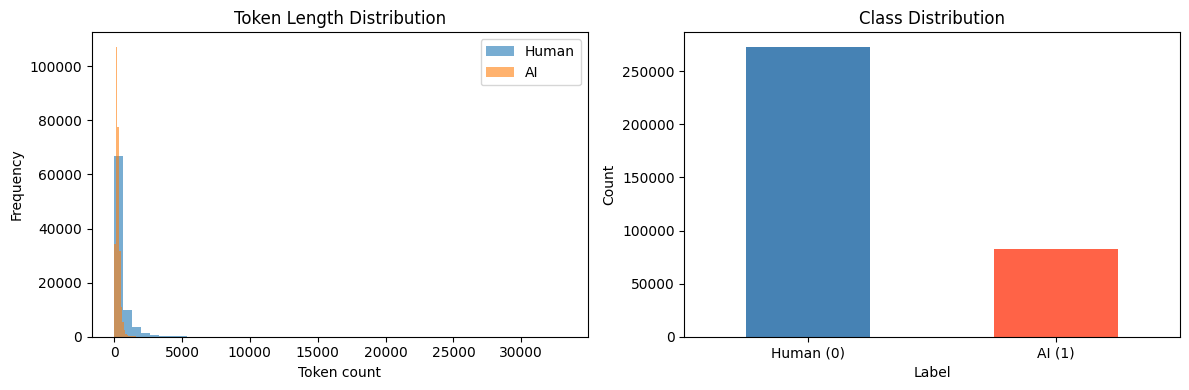

  Saved → /content/drive/MyDrive/AI_Project_Outputs/eda_distributions.pdf


In [ ]:


print("\n=== EDA ===")
print(df_all[["text_clean","label"]].describe())

# Text length distribution
df_all["n_tokens"] = df_all["text_clean"].apply(token_count)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lbl, name in [(0,"Human"), (1,"AI")]:
    subset = df_all[df_all["label"] == lbl]["n_tokens"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=name)
axes[0].set_xlabel("Token count"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Token Length Distribution"); axes[0].legend()

df_all["label"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue","tomato"])
axes[1].set_title("Class Distribution"); axes[1].set_xlabel("Label"); axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Human (0)", "AI (1)"], rotation=0)
plt.tight_layout()
save_fig("eda_distributions")

**SECTION 7: TRAIN / VALIDATION / TEST SPLIT**

In [ ]:
print("\n=== Splitting data 80/10/10 stratified ===")

X = df_all.index.tolist()
y = df_all["label"].tolist()

X_train_idx, X_temp_idx, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
X_val_idx, X_test_idx, y_val, y_test = train_test_split(
    X_temp_idx, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

df_train_split = df_all.loc[X_train_idx].reset_index(drop=True)
df_val_split   = df_all.loc[X_val_idx].reset_index(drop=True)
df_test_split  = df_all.loc[X_test_idx].reset_index(drop=True)

print(f"  Train : {len(df_train_split)}  | class balance: {df_train_split['label'].value_counts().to_dict()}")
print(f"  Val   : {len(df_val_split)}   | class balance: {df_val_split['label'].value_counts().to_dict()}")
print(f"  Test  : {len(df_test_split)}   | class balance: {df_test_split['label'].value_counts().to_dict()}")



=== Splitting data 80/10/10 stratified ===
  Train : 284512  | class balance: {1: 218335, 0: 66177}
  Val   : 35564   | class balance: {1: 27292, 0: 8272}
  Test  : 35564   | class balance: {1: 27292, 0: 8272}


**SECTION 8: METRICS AND PLOTTING UTILITIES**

In [ ]:
def plot_roc(y_true, y_prob, title, fname):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(title); plt.legend()
    save_fig(fname)

def results_table():
    df_res = pd.DataFrame(ALL_RESULTS)
    save_csv(df_res, "all_model_results")
    return df_res

**SECTION 9: FAST MODE SAMPLING — RUN THIS BEFORE EVERYTHING**

In [ ]:
FAST_MODE = True
FAST_N_PER_CLASS = 10000

def fast_sample(df, n_per_class=FAST_N_PER_CLASS, seed=SEED):
    parts = []
    for lbl in [0, 1]:
        sub = df[df["label"] == lbl]
        n = min(n_per_class, len(sub))
        parts.append(sub.sample(n, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

# ── Subsample BEFORE splitting (apply to full df_all) ────────
print(f"Before sampling: {len(df_all)} rows")
df_all = fast_sample(df_all, n_per_class=FAST_N_PER_CLASS)
print(f"After sampling : {len(df_all)} rows")
print(f"Class balance  : {df_all['label'].value_counts().to_dict()}")

# ── Now split the small dataset ──────────────────────────────
X = df_all.index.tolist()
y = df_all["label"].tolist()

X_train_idx, X_temp_idx, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
X_val_idx, X_test_idx, y_val, y_test = train_test_split(
    X_temp_idx, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

df_train_split = df_all.loc[X_train_idx].reset_index(drop=True)
df_val_split   = df_all.loc[X_val_idx].reset_index(drop=True)
df_test_split  = df_all.loc[X_test_idx].reset_index(drop=True)

y_train_np = df_train_split["label"].values
y_val_np   = df_val_split["label"].values
y_test_np  = df_test_split["label"].values

print(f"\nTrain : {len(df_train_split)} | {df_train_split['label'].value_counts().to_dict()}")
print(f"Val   : {len(df_val_split)}  | {df_val_split['label'].value_counts().to_dict()}")
print(f"Test  : {len(df_test_split)}  | {df_test_split['label'].value_counts().to_dict()}")

Before sampling: 355640 rows
After sampling : 20000 rows
Class balance  : {1: 10000, 0: 10000}

Train : 16000 | {1: 8000, 0: 8000}
Val   : 2000  | {1: 1000, 0: 1000}
Test  : 2000  | {0: 1000, 1: 1000}


**SECTION 10: STYLOMETRIC FEATURE EXTRACTION (FAST)**

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm",
                 disable=["ner", "parser", "lemmatizer", "attribute_ruler"])
nlp.add_pipe("sentencizer")

def _extract_from_doc(doc, text):
    tokens = [t for t in doc if not t.is_space]
    words  = [t for t in tokens if t.is_alpha]
    sents  = list(doc.sents)

    if not tokens or not words or not sents:
        return [0.0] * 20

    sent_lens    = [len([t for t in s if t.is_alpha]) for s in sents]
    avg_sent_len = float(np.mean(sent_lens))
    std_sent_len = float(np.std(sent_lens))

    word_lens    = [len(w.text) for w in words]
    avg_word_len = float(np.mean(word_lens))
    std_word_len = float(np.std(word_lens))

    word_forms = [w.text.lower() for w in words]
    ttr   = len(set(word_forms)) / len(word_forms)
    hapax = sum(1 for w in set(word_forms)
                if word_forms.count(w) == 1) / len(word_forms)

    n_tok = max(len(tokens), 1)
    total_chars = max(len(text), 1)

    punct = [t for t in tokens if t.is_punct]
    comma  = sum(1 for t in punct if t.text == ",")  / n_tok
    period = sum(1 for t in punct if t.text == ".")  / n_tok
    excl   = sum(1 for t in punct if t.text == "!")  / n_tok
    quest  = sum(1 for t in punct if t.text == "?")  / n_tok
    semi   = sum(1 for t in punct if t.text == ";")  / n_tok
    colon  = sum(1 for t in punct if t.text == ":")  / n_tok

    digit_ratio = sum(c.isdigit() for c in text) / total_chars
    upper_ratio = sum(c.isupper() for c in text) / total_chars
    space_ratio = sum(c.isspace() for c in text) / total_chars

    pos_counts = {}
    for t in tokens:
        pos_counts[t.pos_] = pos_counts.get(t.pos_, 0) + 1
    noun_ratio = pos_counts.get("NOUN", 0) / n_tok
    verb_ratio = pos_counts.get("VERB", 0) / n_tok
    adj_ratio  = pos_counts.get("ADJ",  0) / n_tok
    adv_ratio  = pos_counts.get("ADV",  0) / n_tok

    return [
        avg_sent_len, std_sent_len, avg_word_len, std_word_len,
        ttr, hapax,
        comma, period, excl, quest, semi, colon,
        digit_ratio, upper_ratio, space_ratio,
        noun_ratio, verb_ratio, adj_ratio, adv_ratio,
        float(len(sents))
    ]

def build_stylo_features(df, desc=""):
    # Cap text at 2000 chars — beyond that features don't change much
    texts = [t[:2000] for t in df["text_clean"].tolist()]
    feats = []
    docs  = nlp.pipe(texts, batch_size=128, n_process=1)
    for doc, text in tqdm(zip(docs, texts), total=len(texts),
                          desc=f"Stylo {desc}"):
        feats.append(_extract_from_doc(doc, text))
    return np.array(feats, dtype=np.float32)

print("Extracting stylometric features...")
X_stylo_train = build_stylo_features(df_train_split, "train")
X_stylo_val   = build_stylo_features(df_val_split,   "val")
X_stylo_test  = build_stylo_features(df_test_split,  "test")
print(f"Feature matrix shape (train): {X_stylo_train.shape}")

Extracting stylometric features...


Stylo train:   0%|          | 0/16000 [00:00<?, ?it/s]

Stylo val:   0%|          | 0/2000 [00:00<?, ?it/s]

Stylo test:   0%|          | 0/2000 [00:00<?, ?it/s]

Feature matrix shape (train): (16000, 20)


**SECTION 11: STYLOMETRIC MODELS (4 models — fast)**

In [ ]:
!pip install -q lightgbm xgboost

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

stylo_scores_train = {}
stylo_scores_val   = {}
stylo_scores_test  = {}

scaler_stylo  = StandardScaler()
X_stylo_tr_sc = scaler_stylo.fit_transform(X_stylo_train)
X_stylo_va_sc = scaler_stylo.transform(X_stylo_val)
X_stylo_te_sc = scaler_stylo.transform(X_stylo_test)

def run_stylo_model(name, clf, X_tr, X_va, X_te):
    clf.fit(X_tr, y_train_np)
    for split, X_s, y_true in [("val", X_va, y_val_np),
                                ("test", X_te, y_test_np)]:
        pred = clf.predict(X_s)
        prob = clf.predict_proba(X_s)[:, 1]
        m = compute_metrics(y_true, pred, prob)
        print_metrics(f"{name} | {split}", m)
        record_result("stylometric", name, split, m)
    stylo_scores_train[name] = clf.predict_proba(X_tr)[:, 1]
    stylo_scores_val[name]   = clf.predict_proba(X_va)[:, 1]
    stylo_scores_test[name]  = clf.predict_proba(X_te)[:, 1]

print("\n[S1] LightGBM")
run_stylo_model("S1_LGBM",
    LGBMClassifier(n_estimators=300, learning_rate=0.05,
                   num_leaves=63, random_state=SEED,
                   n_jobs=-1, verbose=-1),
    X_stylo_tr_sc, X_stylo_va_sc, X_stylo_te_sc)

print("\n[S2] XGBoost")
run_stylo_model("S2_XGB",
    XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                  random_state=SEED, eval_metric="logloss",
                  tree_method="hist",
                  device="cuda" if torch.cuda.is_available() else "cpu",
                  verbosity=0),
    X_stylo_tr_sc, X_stylo_va_sc, X_stylo_te_sc)

print("\n[S3] Logistic Regression")
run_stylo_model("S3_LogReg",
    LogisticRegression(max_iter=500, C=1.0,
                       solver="saga", n_jobs=-1, random_state=SEED),
    X_stylo_tr_sc, X_stylo_va_sc, X_stylo_te_sc)

print("\n[S4] Calibrated LinearSVC")
run_stylo_model("S4_SVM",
    CalibratedClassifierCV(
        LinearSVC(max_iter=1000, random_state=SEED), cv=3),
    X_stylo_tr_sc, X_stylo_va_sc, X_stylo_te_sc)

print("\n✅ Stylometric models done.")


[S1] LightGBM

──────────────────────────────────────────────────
  S1_LGBM | val
──────────────────────────────────────────────────
  accuracy    : 0.7910
  precision   : 0.8012
  recall      : 0.7740
  f1          : 0.7874
  roc_auc     : 0.8731

──────────────────────────────────────────────────
  S1_LGBM | test
──────────────────────────────────────────────────
  accuracy    : 0.8120
  precision   : 0.8164
  recall      : 0.8050
  f1          : 0.8107
  roc_auc     : 0.8938

[S2] XGBoost

──────────────────────────────────────────────────
  S2_XGB | val
──────────────────────────────────────────────────
  accuracy    : 0.7855
  precision   : 0.7898
  recall      : 0.7780
  f1          : 0.7839
  roc_auc     : 0.8711

──────────────────────────────────────────────────
  S2_XGB | test
──────────────────────────────────────────────────
  accuracy    : 0.8080
  precision   : 0.8062
  recall      : 0.8110
  f1          : 0.8086
  roc_auc     : 0.8908

[S3] Logistic Regression

────────

** SECTION 12: SEMANTIC MODELS (4 fast transformers)**

In [ ]:
SEMANTIC_MODELS = {
    "M1_DistilBERT":    "distilbert-base-uncased",
    "M2_DistilRoBERTa": "distilroberta-base",
    "M3_MiniLM":        "microsoft/MiniLM-L12-H384-uncased",
    "M4_Albert":        "albert-base-v2",   # replaces DeBERTa — no FP16 issues
}

# Models that do NOT support AMP/FP16 — will train in FP32
NO_AMP_MODELS = {"M4_Albert"}

MAX_LEN    = 96
BATCH_SIZE = 32 if torch.cuda.is_available() else 8
EPOCHS     = 2

semantic_scores_train = {}
semantic_scores_val   = {}
semantic_scores_test  = {}

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def train_semantic_model(model_key, model_name):
    print(f"\n[{model_key}] {model_name}")
    set_seed(SEED)

    use_amp = torch.cuda.is_available() and (model_key not in NO_AMP_MODELS)
    print(f"  AMP (mixed precision): {'ON' if use_amp else 'OFF'}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True)

    # Freeze bottom layers for speed
    frozen = 0
    for attr in ["bert", "roberta", "albert", "distilbert", "deberta"]:
        if hasattr(model, attr):
            base = getattr(model, attr)
            if attr == "distilbert":
                layers = base.transformer.layer
            elif attr == "albert":
                # Albert shares layers — just freeze embeddings
                for p in base.embeddings.parameters():
                    p.requires_grad = False
                print(f"  Froze Albert embeddings")
                layers = []
            else:
                layers = base.encoder.layer
            for layer in layers[:4]:
                for p in layer.parameters():
                    p.requires_grad = False
                frozen += 1
            if frozen:
                print(f"  Froze first {frozen} transformer layers")
            break

    model = model.to(DEVICE)

    def tokenize(texts):
        return tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=MAX_LEN, return_tensors=None)

    enc_train = tokenize(df_train_split["text_clean"].tolist())
    enc_val   = tokenize(df_val_split["text_clean"].tolist())
    enc_test  = tokenize(df_test_split["text_clean"].tolist())

    ds_train = TextDataset(enc_train, y_train_np.tolist())
    ds_val   = TextDataset(enc_val,   y_val_np.tolist())
    ds_test  = TextDataset(enc_test,  y_test_np.tolist())

    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE * 2,
                          shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE * 2,
                          shuffle=False, num_workers=0, pin_memory=True)

    from transformers import get_linear_schedule_with_warmup
    total_steps = len(train_loader) * EPOCHS
    optimizer   = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-5, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=total_steps // 10,
        num_training_steps=total_steps)

    # Only create GradScaler if AMP is enabled
    scaler_amp = torch.cuda.amp.GradScaler() if use_amp else None

    best_val_f1, best_state = -1, None

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader,
                          desc=f"  Epoch {epoch+1}/{EPOCHS}", leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()

            if use_amp:
                with torch.cuda.amp.autocast():
                    loss = model(**batch).loss
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler_amp.step(optimizer)
                scaler_amp.update()
            else:
                loss = model(**batch).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_probs = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch  = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                all_probs.extend(
                    torch.softmax(logits, -1)[:, 1].cpu().numpy())
                all_preds.extend(logits.argmax(-1).cpu().numpy())

        val_f1 = f1_score(y_val_np, all_preds, zero_division=0)
        print(f"  Epoch {epoch+1} | loss={total_loss/len(train_loader):.4f}"
              f" | val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone()
                           for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model = model.to(DEVICE)

    def get_probs(loader):
        model.eval()
        probs = []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                p = torch.softmax(model(**batch).logits, -1)[:, 1].cpu().numpy()
                probs.extend(p)
        return np.array(probs)

    tr_probs  = get_probs(DataLoader(ds_train, batch_size=BATCH_SIZE * 2))
    val_probs = get_probs(val_loader)
    te_probs  = get_probs(test_loader)

    for split, probs, y_true in [("val",  val_probs, y_val_np),
                                  ("test", te_probs,  y_test_np)]:
        preds = (probs >= 0.5).astype(int)
        m     = compute_metrics(y_true, preds, probs)
        print_metrics(f"{model_key} | {split}", m)
        record_result("semantic", model_key, split, m)

    semantic_scores_train[model_key] = tr_probs
    semantic_scores_val[model_key]   = val_probs
    semantic_scores_test[model_key]  = te_probs

    del model
    torch.cuda.empty_cache()

for mk, mn in SEMANTIC_MODELS.items():
    train_semantic_model(mk, mn)

print("\n✅ Semantic models done.")


[M1_DistilBERT] distilbert-base-uncased
  AMP (mixed precision): ON


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Froze Albert embeddings


  Epoch 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

  Epoch 1 | loss=0.3900 | val_f1=0.8701


  Epoch 2/2:   0%|          | 0/500 [00:00<?, ?it/s]

  Epoch 2 | loss=0.2280 | val_f1=0.8888

──────────────────────────────────────────────────
  M4_Albert | val
──────────────────────────────────────────────────
  accuracy    : 0.8890
  precision   : 0.8906
  recall      : 0.8870
  f1          : 0.8888
  roc_auc     : 0.9589

──────────────────────────────────────────────────
  M4_Albert | test
──────────────────────────────────────────────────
  accuracy    : 0.9000
  precision   : 0.8960
  recall      : 0.9050
  f1          : 0.9005
  roc_auc     : 0.9618

✅ Semantic models done.


**SECTION 13: PERPLEXITY / GENERATION-TRACE MODELS (fast)**

In [ ]:

TRACE_LM_NAMES = {
    "distilgpt2": "distilgpt2",
    "gpt2":       "gpt2",
}

def compute_nll_batch(texts, lm_model, lm_tokenizer,
                      batch_size=64, max_len=128):
    """Returns per-text mean NLL (fast batched version)."""
    results = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        enc = lm_tokenizer(
            batch_texts, return_tensors="pt", truncation=True,
            max_length=max_len, padding=True)
        input_ids      = enc["input_ids"].to(DEVICE)
        attention_mask = enc["attention_mask"].to(DEVICE)
        with torch.no_grad():
            out = lm_model(input_ids,
                           attention_mask=attention_mask,
                           labels=input_ids)
        # out.loss is mean NLL over the whole batch
        # get per-sample NLL via manual loop on logits
        logits = out.logits[:, :-1, :].contiguous()
        target = input_ids[:, 1:].contiguous()
        loss_fn = nn.CrossEntropyLoss(reduction="none")
        token_loss = loss_fn(
            logits.view(-1, logits.size(-1)),
            target.view(-1)
        ).view(target.size())  # (B, T-1)
        mask = attention_mask[:, 1:].float()
        mean_nll = (token_loss * mask).sum(1) / mask.sum(1).clamp(min=1)
        results.extend(mean_nll.cpu().numpy().tolist())
    return np.array(results, dtype=np.float32)

def build_trace_feature_matrix(df, lm_dict, desc=""):
    texts = df["text_raw"].tolist()
    nll_dict = {}
    for lm_name, (lm_model, lm_tok) in lm_dict.items():
        print(f"  Computing NLL for {lm_name} ({desc})…")
        nll_dict[lm_name] = compute_nll_batch(texts, lm_model, lm_tok)

    rows = []
    for i in range(len(texts)):
        row = {}
        for lm_name, nlls in nll_dict.items():
            nll = nlls[i]
            row[f"{lm_name}_mean_nll"] = nll
            row[f"{lm_name}_perplexity"] = float(np.exp(min(nll, 20)))
        # pairwise diff
        lm_names = list(nll_dict.keys())
        for a, b in itertools.combinations(lm_names, 2):
            row[f"nll_diff_{a}_vs_{b}"] = (
                nll_dict[a][i] - nll_dict[b][i])
        rows.append(row)
    return pd.DataFrame(rows)

# ── Load LMs ────────────────────────────────────────────────
print("Loading causal LMs…")
lm_dict = {}
for name, path in TRACE_LM_NAMES.items():
    tok = AutoTokenizer.from_pretrained(path)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(path).to(DEVICE)
    mdl.eval()
    lm_dict[name] = (mdl, tok)

# ── Extract features ─────────────────────────────────────────
trace_train_df = build_trace_feature_matrix(df_train_split, lm_dict, "train")
trace_val_df   = build_trace_feature_matrix(df_val_split,   lm_dict, "val")
trace_test_df  = build_trace_feature_matrix(df_test_split,  lm_dict, "test")

save_csv(trace_train_df, "trace_features_train")
save_csv(trace_val_df,   "trace_features_val")
save_csv(trace_test_df,  "trace_features_test")

X_trace_train = trace_train_df.values.astype(np.float32)
X_trace_val   = trace_val_df.values.astype(np.float32)
X_trace_test  = trace_test_df.values.astype(np.float32)

for name in list(lm_dict.keys()):
    del lm_dict[name]
torch.cuda.empty_cache()
print("LMs freed from GPU memory.")

scaler_trace  = StandardScaler()
X_tr_sc = scaler_trace.fit_transform(X_trace_train)
X_va_sc = scaler_trace.transform(X_trace_val)
X_te_sc = scaler_trace.transform(X_trace_test)

trace_scores_train = {}
trace_scores_val   = {}
trace_scores_test  = {}

def run_trace_model(key, clf, X_tr, X_va, X_te):
    clf.fit(X_tr, y_train_np)
    for split, X_s, y_true in [("val",  X_va, y_val_np),
                                ("test", X_te, y_test_np)]:
        pred = clf.predict(X_s)
        prob = clf.predict_proba(X_s)[:, 1]
        m    = compute_metrics(y_true, pred, prob)
        print_metrics(f"{key} | {split}", m)
        record_result("perplexity", key, split, m)
    trace_scores_train[key] = clf.predict_proba(X_tr)[:, 1]
    trace_scores_val[key]   = clf.predict_proba(X_va)[:, 1]
    trace_scores_test[key]  = clf.predict_proba(X_te)[:, 1]

# Columns per model
dgpt2_idx = [i for i,c in enumerate(trace_train_df.columns)
             if c.startswith("distilgpt2")]
gpt2_idx  = [i for i,c in enumerate(trace_train_df.columns)
             if c.startswith("gpt2")]
all_idx   = list(range(X_tr_sc.shape[1]))

print("\n[P1] distilgpt2 → LogReg")
run_trace_model("P1_distilgpt2",
    LogisticRegression(max_iter=500, random_state=SEED),
    X_tr_sc[:,dgpt2_idx], X_va_sc[:,dgpt2_idx], X_te_sc[:,dgpt2_idx])

print("\n[P2] gpt2 → LogReg")
run_trace_model("P2_gpt2",
    LogisticRegression(max_iter=500, random_state=SEED),
    X_tr_sc[:,gpt2_idx], X_va_sc[:,gpt2_idx], X_te_sc[:,gpt2_idx])

print("\n[P3] gpt2 → MLP")
run_trace_model("P3_gpt2_MLP",
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                  random_state=SEED, early_stopping=True),
    X_tr_sc[:,gpt2_idx], X_va_sc[:,gpt2_idx], X_te_sc[:,gpt2_idx])

print("\n[P4] All features (diff included) → LightGBM")
run_trace_model("P4_MultiDiff_LGBM",
    LGBMClassifier(n_estimators=200, learning_rate=0.05,
                   num_leaves=31, random_state=SEED,
                   n_jobs=-1, verbose=-1),
    X_tr_sc[:,all_idx], X_va_sc[:,all_idx], X_te_sc[:,all_idx])

print("\n✅ Perplexity/trace models done.")

Loading causal LMs…


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Computing NLL for distilgpt2 (train)…
  Computing NLL for gpt2 (train)…
  Computing NLL for distilgpt2 (val)…
  Computing NLL for gpt2 (val)…
  Computing NLL for distilgpt2 (test)…
  Computing NLL for gpt2 (test)…
  Saved → /content/drive/MyDrive/AI_Project_Outputs/trace_features_train.csv
  Saved → /content/drive/MyDrive/AI_Project_Outputs/trace_features_val.csv
  Saved → /content/drive/MyDrive/AI_Project_Outputs/trace_features_test.csv
LMs freed from GPU memory.

[P1] distilgpt2 → LogReg

──────────────────────────────────────────────────
  P1_distilgpt2 | val
──────────────────────────────────────────────────
  accuracy    : 0.5855
  precision   : 0.5839
  recall      : 0.5950
  f1          : 0.5894
  roc_auc     : 0.6405

──────────────────────────────────────────────────
  P1_distilgpt2 | test
──────────────────────────────────────────────────
  accuracy    : 0.6070
  precision   : 0.6035
  recall      : 0.6240
  f1          : 0.6136
  roc_auc     : 0.6516

[P2] gpt2 → LogReg

─

 **SECTION 14: MODEL SELECTION WITHIN EACH FAMILY**

In [ ]:

print("\n=== Selecting Top-2 Models Per Family ===")

df_res = pd.DataFrame(ALL_RESULTS)

def top2_in_family(family):
    sub = df_res[(df_res["family"] == family) & (df_res["split"] == "val")]
    sub = sub.sort_values(["f1","roc_auc"], ascending=False)
    top = sub.drop_duplicates("model").head(2)["model"].tolist()
    return top

top2_stylo = top2_in_family("stylometric")
top2_sem   = top2_in_family("semantic")
top2_trace = top2_in_family("perplexity")

print(f"\n  Best 2 Stylometric  : {top2_stylo}")
print(f"  Best 2 Semantic     : {top2_sem}")
print(f"  Best 2 Perplexity   : {top2_trace}")

# Unified score dicts for convenience
all_scores_train = {}
all_scores_val   = {}
all_scores_test  = {}

all_scores_train.update(stylo_scores_train)
all_scores_train.update(semantic_scores_train)
all_scores_train.update(trace_scores_train)

all_scores_val.update(stylo_scores_val)
all_scores_val.update(semantic_scores_val)
all_scores_val.update(trace_scores_val)

all_scores_test.update(stylo_scores_test)
all_scores_test.update(semantic_scores_test)
all_scores_test.update(trace_scores_test)


=== Selecting Top-2 Models Per Family ===

  Best 2 Stylometric  : ['S1_LGBM', 'S2_XGB']
  Best 2 Semantic     : ['M4_Albert', 'M3_MiniLM']
  Best 2 Perplexity   : ['P4_MultiDiff_LGBM', 'P2_gpt2']


**SECTION 15: FUSION COMBINATION SEARCH (8 combos = 2×2×2)**


=== Fusion Combination Search ===
  Combos: 2 × 2 × 2 = 8 combinations

  Combo: S1_LGBM+M4_Albert+P4_MultiDiff_LGBM
    val  F1=0.8751  AUC=0.9511
    test F1=0.8944  AUC=0.9578

  Combo: S1_LGBM+M4_Albert+P2_gpt2
    val  F1=0.8724  AUC=0.9505
    test F1=0.8940  AUC=0.9581

  Combo: S1_LGBM+M3_MiniLM+P4_MultiDiff_LGBM
    val  F1=0.8491  AUC=0.9353
    test F1=0.8691  AUC=0.9438

  Combo: S1_LGBM+M3_MiniLM+P2_gpt2
    val  F1=0.8483  AUC=0.9340
    test F1=0.8663  AUC=0.9438

  Combo: S2_XGB+M4_Albert+P4_MultiDiff_LGBM
    val  F1=0.9036  AUC=0.9584
    test F1=0.9084  AUC=0.9638

  Combo: S2_XGB+M4_Albert+P2_gpt2
    val  F1=0.8952  AUC=0.9584
    test F1=0.9116  AUC=0.9643

  Combo: S2_XGB+M3_MiniLM+P4_MultiDiff_LGBM
    val  F1=0.8630  AUC=0.9444
    test F1=0.8870  AUC=0.9512

  Combo: S2_XGB+M3_MiniLM+P2_gpt2
    val  F1=0.8574  AUC=0.9439
    test F1=0.8888  AUC=0.9519

  🏆  BEST FUSION COMBINATION
      S2_XGB+M4_Albert+P4_MultiDiff_LGBM
      Val  F1=0.9036  AUC=0.9584
    

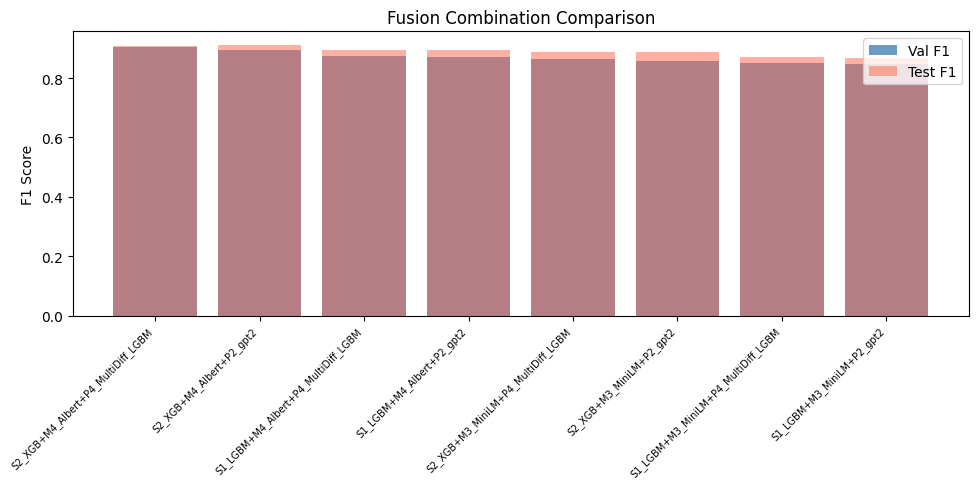

  Saved → /content/drive/MyDrive/AI_Project_Outputs/fusion_comparison.pdf


In [ ]:

print("\n=== Fusion Combination Search ===")
print(f"  Combos: {len(top2_stylo)} × {len(top2_sem)} × {len(top2_trace)} = "
      f"{len(top2_stylo)*len(top2_sem)*len(top2_trace)} combinations")

fusion_results = []

for s_name, sem_name, p_name in itertools.product(top2_stylo, top2_sem, top2_trace):
    combo_name = f"{s_name}+{sem_name}+{p_name}"
    print(f"\n  Combo: {combo_name}")

    # ── Build feature matrices ─────────────────────────────
    def stack_scores(score_dict, names):
        return np.column_stack([score_dict[n] for n in names])

    trio = [s_name, sem_name, p_name]

    F_train = stack_scores(all_scores_train, trio)
    F_val   = stack_scores(all_scores_val,   trio)
    F_test  = stack_scores(all_scores_test,  trio)

    # ── Train fusion classifier (Logistic Regression) ──────
    fusion_clf = LogisticRegression(max_iter=500, random_state=SEED)
    fusion_clf.fit(F_train, y_train_np)

    # ── Val metrics ───────────────────────────────────────
    val_pred = fusion_clf.predict(F_val)
    val_prob = fusion_clf.predict_proba(F_val)[:,1]
    val_m    = compute_metrics(y_val_np, val_pred, val_prob)

    # ── Test metrics ──────────────────────────────────────
    te_pred = fusion_clf.predict(F_test)
    te_prob = fusion_clf.predict_proba(F_test)[:,1]
    te_m    = compute_metrics(y_test_np, te_pred, te_prob)

    print(f"    val  F1={val_m['f1']:.4f}  AUC={val_m['roc_auc']:.4f}")
    print(f"    test F1={te_m['f1']:.4f}  AUC={te_m['roc_auc']:.4f}")

    fusion_results.append({
        "combo":         combo_name,
        "stylo":         s_name,
        "semantic":      sem_name,
        "perplexity":    p_name,
        "val_f1":        val_m["f1"],
        "val_auc":       val_m["roc_auc"],
        "test_f1":       te_m["f1"],
        "test_auc":      te_m["roc_auc"],
        "val_acc":       val_m["accuracy"],
        "test_acc":      te_m["accuracy"],
        "clf":           fusion_clf,
        "trio":          trio,
    })

# ── Rank combos ───────────────────────────────────────────────
fusion_results.sort(key=lambda x: (x["val_f1"], x["val_auc"]), reverse=True)
best = fusion_results[0]

print(f"\n{'='*60}")
print(f"  🏆  BEST FUSION COMBINATION")
print(f"      {best['combo']}")
print(f"      Val  F1={best['val_f1']:.4f}  AUC={best['val_auc']:.4f}")
print(f"      Test F1={best['test_f1']:.4f}  AUC={best['test_auc']:.4f}")
print(f"{'='*60}")

# Save fusion results table
fusion_df = pd.DataFrame([{
    "combo":    r["combo"], "val_f1":  r["val_f1"],
    "val_auc":  r["val_auc"], "test_f1": r["test_f1"],
    "test_auc": r["test_auc"], "val_acc": r["val_acc"],
    "test_acc": r["test_acc"],
} for r in fusion_results])
save_csv(fusion_df, "fusion_combination_results")

# ── Plot fusion comparison ────────────────────────────────────
plt.figure(figsize=(10, 5))
x = range(len(fusion_df))
plt.bar(x, fusion_df["val_f1"], color="steelblue", alpha=0.8, label="Val F1")
plt.bar(x, fusion_df["test_f1"], color="tomato", alpha=0.5, label="Test F1")
plt.xticks(x, fusion_df["combo"], rotation=45, ha="right", fontsize=7)
plt.ylabel("F1 Score"); plt.title("Fusion Combination Comparison")
plt.legend(); plt.tight_layout()
save_fig("fusion_comparison")


**SECTION 16: FINAL EVALUATION**

In [ ]:
print("\n=== Final Evaluation (Best Combination) ===")

best_clf  = best["clf"]
best_trio = best["trio"]

F_test_best = np.column_stack([all_scores_test[n] for n in best_trio])
final_pred  = best_clf.predict(F_test_best)
final_prob  = best_clf.predict_proba(F_test_best)[:,1]
final_m     = compute_metrics(y_test_np, final_pred, final_prob)

print_metrics(f"FINAL SYSTEM ({best['combo']})", final_m)
record_result("fusion", best["combo"], "test_final", final_m)

# ── Print all 12 individual model results summary ─────────────
print("\n\n=== ALL 12 INDIVIDUAL MODEL RESULTS (Val) ===")
df_res = pd.DataFrame(ALL_RESULTS).drop_duplicates(
    subset=["family", "model", "split", "accuracy", "precision", "recall", "f1", "roc_auc"]
).reset_index(drop=True)

val_summary = df_res[df_res["split"] == "val"][
    ["family","model","f1","roc_auc","accuracy"]
].sort_values(["family","f1"], ascending=[True, False])
print(val_summary.to_string(index=False))
save_csv(val_summary, "individual_model_summary_val")

# ── Selected 6 models ─────────────────────────────────────────
print("\n=== SELECTED TOP-2 PER FAMILY ===")
for f, top2 in [("Stylometric", top2_stylo),
                ("Semantic",    top2_sem),
                ("Perplexity",  top2_trace)]:
    print(f"  {f}: {top2}")

# ── All 8 fusion combos table ─────────────────────────────────
print("\n=== ALL 8 FUSION COMBINATION RESULTS ===")
print(fusion_df[["combo","val_f1","val_auc","test_f1","test_auc"]].to_string(index=False))

# ── Best combo ────────────────────────────────────────────────
print(f"\n=== BEST FINAL 3-MODEL COMBINATION ===")
print(f"  Combination : {best['combo']}")
print(f"  Test F1     : {best['test_f1']:.4f}")
print(f"  Test AUC    : {best['test_auc']:.4f}")
print(f"  Test Acc    : {best['test_acc']:.4f}")
print(f"  Test Prec   : {final_m['precision']:.4f}")
print(f"  Test Recall : {final_m['recall']:.4f}")



=== Final Evaluation (Best Combination) ===

──────────────────────────────────────────────────
  FINAL SYSTEM (S2_XGB+M4_Albert+P4_MultiDiff_LGBM)
──────────────────────────────────────────────────
  accuracy    : 0.9075
  precision   : 0.8999
  recall      : 0.9170
  f1          : 0.9084
  roc_auc     : 0.9638


=== ALL 12 INDIVIDUAL MODEL RESULTS (Val) ===
     family             model       f1  roc_auc  accuracy
 perplexity P4_MultiDiff_LGBM 0.619321 0.685023    0.6355
 perplexity           P2_gpt2 0.602398 0.662463    0.6020
 perplexity     P1_distilgpt2 0.589401 0.640505    0.5855
 perplexity       P3_gpt2_MLP 0.570166 0.662459    0.6110
   semantic         M4_Albert 0.888778 0.958893    0.8890
   semantic         M3_MiniLM 0.866127 0.942772    0.8595
   semantic     M1_DistilBERT 0.862577 0.944114    0.8555
   semantic  M2_DistilRoBERTa 0.861253 0.949703    0.8505
stylometric           S1_LGBM 0.787386 0.873137    0.7910
stylometric            S2_XGB 0.783879 0.871058    0.7855

**SECTION 17: ERROR ANALYSIS (IMPROVED FOR PAPER)**


=== Error Analysis ===


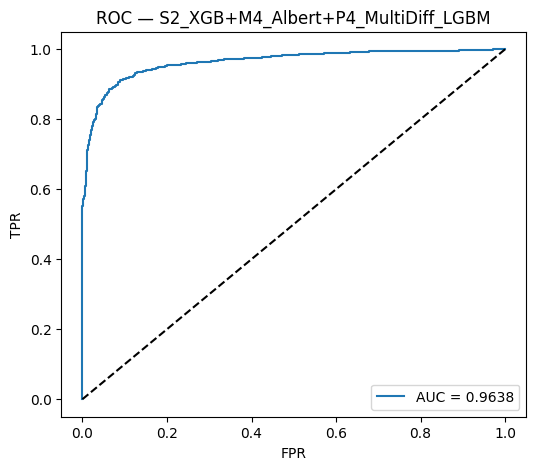

  Saved → /content/drive/MyDrive/AI_Project_Outputs/final_roc_curve.pdf


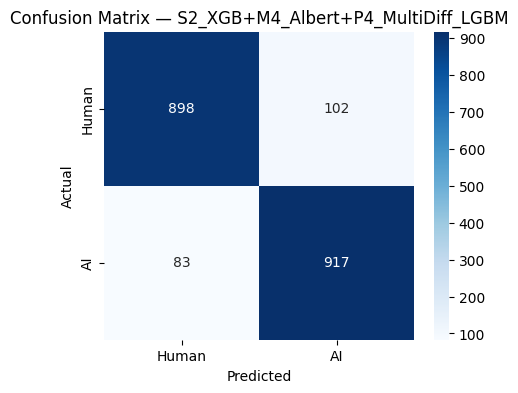

  Saved → /content/drive/MyDrive/AI_Project_Outputs/final_confusion_matrix.pdf

Test samples                 : 2000
Correct predictions          : 1815
Misclassified samples        : 185
Error rate                   : 0.0925
False Positives (Human→AI)   : 102
False Negatives (AI→Human)   : 83


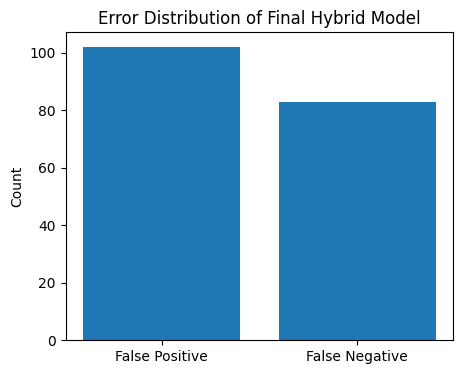

  Saved → /content/drive/MyDrive/AI_Project_Outputs/error_distribution_bar.pdf

Average token length by prediction group:
         group  avg_tokens
 True Negative  555.922049
False Positive  398.656863
False Negative  299.457831
 True Positive  264.945474


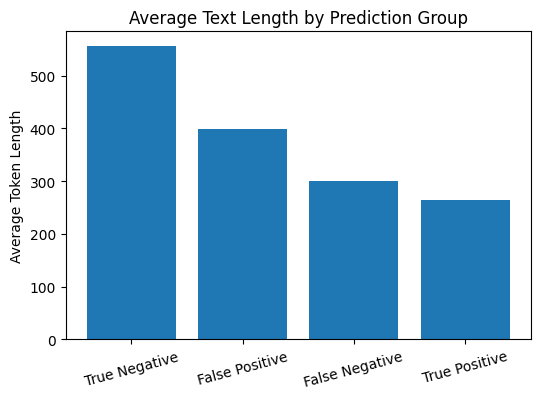

  Saved → /content/drive/MyDrive/AI_Project_Outputs/error_length_analysis.pdf

--- Top False Positives (Human predicted as AI) ---
[prob_ai=0.995 | tokens=45] The paper addresses the important problem (d>>n) in deep learning. The proposed approach, based on lower-dimensional feature embeddings, is reasonable and makes applying deep learn...

[prob_ai=0.994 | tokens=974] Gun laws in the state of Georgia regulate the sale, possession, and use of firearms and ammunition in the state of Georgia in the United States. The Georgia Constitution, like many...

[prob_ai=0.994 | tokens=198] This list of Nevada state parks comprises protected areas managed by the U.S. state of Nevada, which include state parks, state historic sites, and state recreation areas. The syst...


--- Top False Negatives (AI predicted as Human) ---
[prob_ai=0.001 | tokens=238] *BAM* A loud sound cracks across the intersection as if a bomb just went off but in reality, it was the sound of a SUV running into the back of a 

In [ ]:
print("\n=== Error Analysis ===")

# ------------------------------------------------------------
# 1. ROC CURVE
# ------------------------------------------------------------
plot_roc(y_test_np, final_prob, f"ROC — {best['combo']}", "final_roc_curve")

# ------------------------------------------------------------
# 2. CONFUSION MATRIX
# ------------------------------------------------------------
plot_confusion(
    y_test_np,
    final_pred,
    f"Confusion Matrix — {best['combo']}",
    "final_confusion_matrix"
)

# ------------------------------------------------------------
# 3. BUILD ERROR ANALYSIS DATAFRAME
# ------------------------------------------------------------
df_test_copy = df_test_split.copy()
df_test_copy["pred"] = final_pred
df_test_copy["prob_ai"] = final_prob
df_test_copy["correct"] = (df_test_copy["pred"] == df_test_copy["label"]).astype(int)
df_test_copy["n_tokens"] = df_test_copy["text_clean"].apply(lambda x: len(str(x).split()))

# Error groups
fp = df_test_copy[(df_test_copy["label"] == 0) & (df_test_copy["pred"] == 1)].copy()
fn = df_test_copy[(df_test_copy["label"] == 1) & (df_test_copy["pred"] == 0)].copy()
tp = df_test_copy[(df_test_copy["label"] == 1) & (df_test_copy["pred"] == 1)].copy()
tn = df_test_copy[(df_test_copy["label"] == 0) & (df_test_copy["pred"] == 0)].copy()

total_errors = len(fp) + len(fn)
error_rate = total_errors / len(df_test_copy)

print(f"\nTest samples                 : {len(df_test_copy)}")
print(f"Correct predictions          : {len(df_test_copy) - total_errors}")
print(f"Misclassified samples        : {total_errors}")
print(f"Error rate                   : {error_rate:.4f}")
print(f"False Positives (Human→AI)   : {len(fp)}")
print(f"False Negatives (AI→Human)   : {len(fn)}")

# ------------------------------------------------------------
# 4. ERROR DISTRIBUTION BAR CHART
# ------------------------------------------------------------
plt.figure(figsize=(5, 4))
plt.bar(["False Positive", "False Negative"], [len(fp), len(fn)])
plt.ylabel("Count")
plt.title("Error Distribution of Final Hybrid Model")
save_fig("error_distribution_bar")

# ------------------------------------------------------------
# 5. TEXT LENGTH ANALYSIS
# ------------------------------------------------------------
length_stats = pd.DataFrame({
    "group": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "avg_tokens": [
        tn["n_tokens"].mean() if len(tn) else 0,
        fp["n_tokens"].mean() if len(fp) else 0,
        fn["n_tokens"].mean() if len(fn) else 0,
        tp["n_tokens"].mean() if len(tp) else 0,
    ]
})

print("\nAverage token length by prediction group:")
print(length_stats.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(length_stats["group"], length_stats["avg_tokens"])
plt.ylabel("Average Token Length")
plt.title("Average Text Length by Prediction Group")
plt.xticks(rotation=15)
save_fig("error_length_analysis")

# ------------------------------------------------------------
# 6. MOST CONFIDENT ERRORS
# ------------------------------------------------------------
# For FP, high prob_ai means stronger wrong AI prediction
fp_sorted = fp.sort_values("prob_ai", ascending=False).copy()

# For FN, low prob_ai means stronger wrong Human prediction
fn_sorted = fn.sort_values("prob_ai", ascending=True).copy()

def shorten_text(text, max_len=180):
    text = str(text).replace("\n", " ").strip()
    return text if len(text) <= max_len else text[:max_len] + "..."

fp_sorted["text_short"] = fp_sorted["text_clean"].apply(shorten_text)
fn_sorted["text_short"] = fn_sorted["text_clean"].apply(shorten_text)
tp["text_short"] = tp["text_clean"].apply(shorten_text)
tn["text_short"] = tn["text_clean"].apply(shorten_text)

print("\n--- Top False Positives (Human predicted as AI) ---")
for _, row in fp_sorted.head(3).iterrows():
    print(f"[prob_ai={row['prob_ai']:.3f} | tokens={row['n_tokens']}] {row['text_short']}")
    print()

print("\n--- Top False Negatives (AI predicted as Human) ---")
for _, row in fn_sorted.head(3).iterrows():
    print(f"[prob_ai={row['prob_ai']:.3f} | tokens={row['n_tokens']}] {row['text_short']}")
    print()

# ------------------------------------------------------------
# 7. SAVE TABLES FOR PAPER
# ------------------------------------------------------------
paper_examples = pd.concat([
    tn.head(2).assign(status="Correct"),
    tp.head(2).assign(status="Correct"),
    fp_sorted.head(2).assign(status="Misclassified"),
    fn_sorted.head(2).assign(status="Misclassified"),
], ignore_index=True)

paper_examples["actual_label"] = paper_examples["label"].map({0: "Human", 1: "AI"})
paper_examples["pred_label"] = paper_examples["pred"].map({0: "Human", 1: "AI"})

paper_examples = paper_examples[[
    "text_short", "actual_label", "pred_label", "status", "prob_ai", "n_tokens"
]].rename(columns={
    "text_short": "Text Sample (Short)",
    "actual_label": "Actual",
    "pred_label": "Pred.",
    "status": "Status",
    "prob_ai": "P(AI)",
    "n_tokens": "Tokens"
})

save_csv(fp_sorted[["text_clean", "label", "pred", "prob_ai", "n_tokens"]].head(20), "false_positives")
save_csv(fn_sorted[["text_clean", "label", "pred", "prob_ai", "n_tokens"]].head(20), "false_negatives")
save_csv(length_stats, "error_length_stats")
save_csv(paper_examples, "paper_error_examples")

print("\n✅ Improved error analysis outputs saved.")

**SECTION 17B: QUALITATIVE ERROR ANALYSIS TABLES FOR PAPER**

  Saved → /content/drive/MyDrive/AI_Project_Outputs/qualitative_examples_table.csv


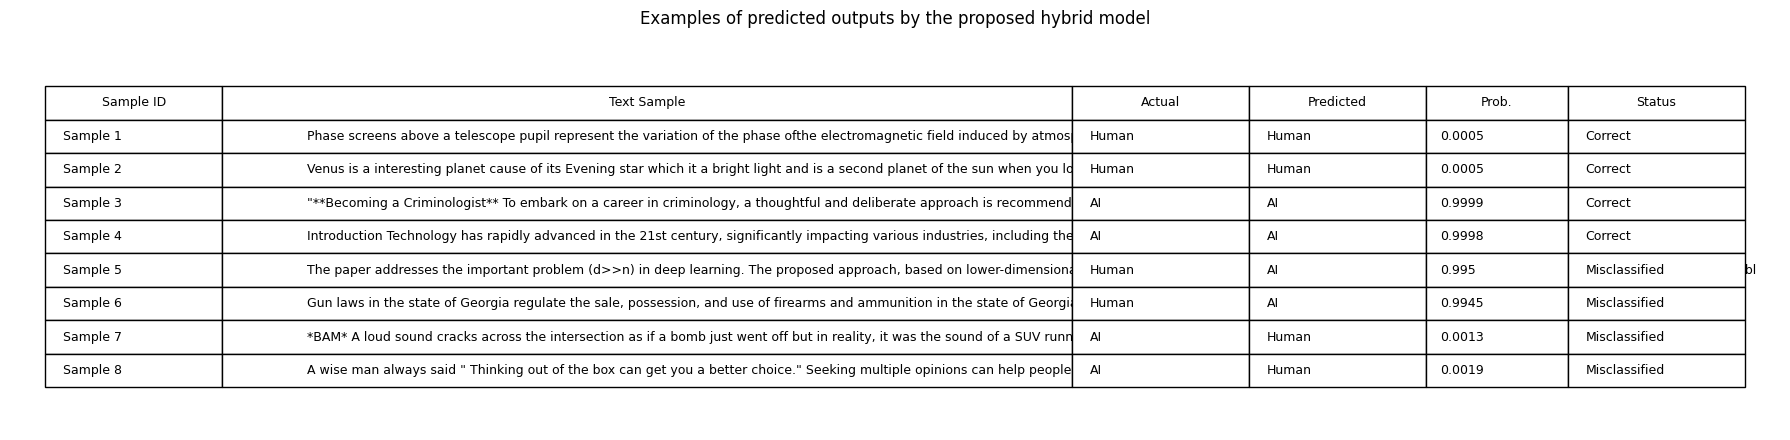

Saved → /content/drive/MyDrive/AI_Project_Outputs/qualitative_examples_table.png
  Saved → /content/drive/MyDrive/AI_Project_Outputs/false_positive_examples_table.csv
  Saved → /content/drive/MyDrive/AI_Project_Outputs/false_negative_examples_table.csv


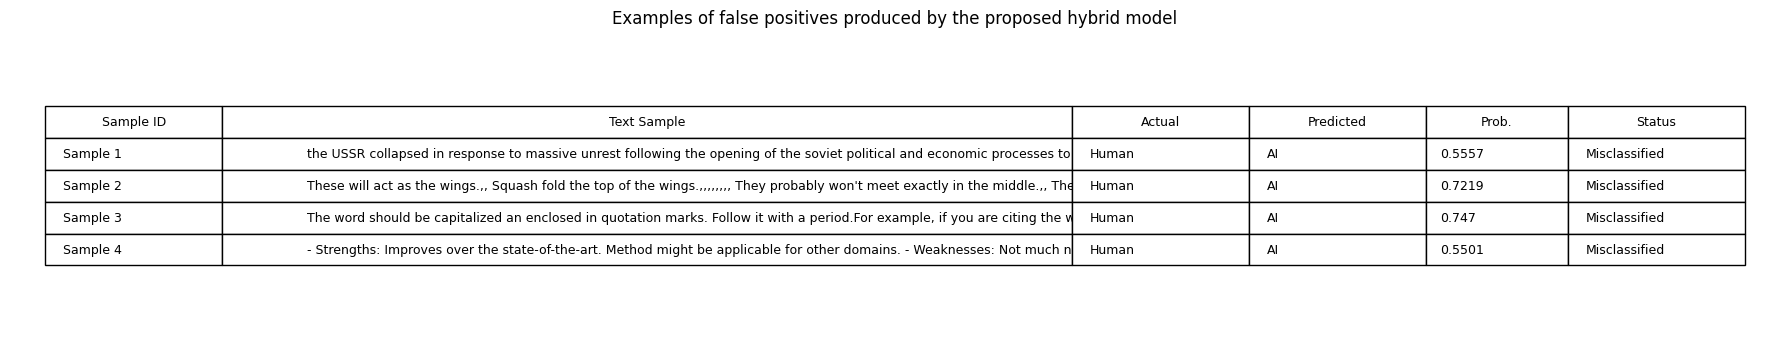

Saved → /content/drive/MyDrive/AI_Project_Outputs/false_positive_examples_table.png


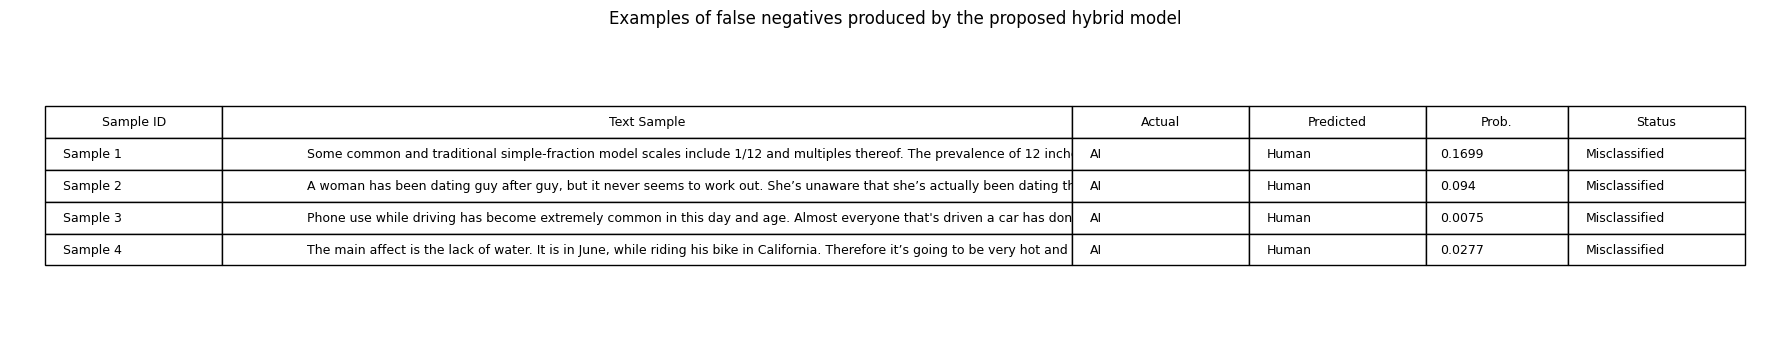

Saved → /content/drive/MyDrive/AI_Project_Outputs/false_negative_examples_table.png


In [ ]:
def build_prediction_examples_table(df_examples, label_map={0: "Human", 1: "AI"}, n=4):
    """
    Build a paper-style table with:
    Sample ID | Text Sample | Actual | Predicted | Probability | Status
    """
    rows = []
    df_examples = df_examples.head(n).copy().reset_index(drop=True)

    for i, row in df_examples.iterrows():
        rows.append({
            "Sample ID": f"Sample {i+1}",
            "Text Sample": row["text_clean"][:220].replace("\n", " ").strip(),
            "Actual": label_map[int(row["label"])],
            "Predicted": label_map[int(row["pred"])],
            "Probability": round(float(row["prob"]), 4),
            "Status": "Correct" if int(row["label"]) == int(row["pred"]) else "Misclassified"
        })

    return pd.DataFrame(rows)

def save_examples_table_image(df_table, title, out_png, figsize=(14, 2.8)):
    """
    Save a paper-style image table similar to your example figures.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    wrapped_rows = []
    for _, r in df_table.iterrows():
        wrapped_rows.append([
            r["Sample ID"],
            r["Text Sample"],
            r["Actual"],
            r["Predicted"],
            str(r["Probability"]),
            r["Status"]
        ])

    col_labels = ["Sample ID", "Text Sample", "Actual", "Predicted", "Prob.", "Status"]

    table = ax.table(
        cellText=wrapped_rows,
        colLabels=col_labels,
        loc="center",
        cellLoc="left",
        colLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)

    # widen text column
    col_widths = [0.10, 0.48, 0.10, 0.10, 0.08, 0.10]
    for i, w in enumerate(col_widths):
        for j in range(len(df_table) + 1):
            table[(j, i)].set_width(w)

    plt.title(title, fontsize=12, pad=14)
    plt.tight_layout()
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_png}")

# Build copies again
df_test_copy = df_test_split.copy()
df_test_copy["pred"] = final_pred
df_test_copy["prob"] = final_prob
df_test_copy["correct"] = (df_test_copy["pred"] == df_test_copy["label"]).astype(int)

# False positives / false negatives
fp = df_test_copy[(df_test_copy["label"] == 0) & (df_test_copy["pred"] == 1)].copy()
fn = df_test_copy[(df_test_copy["label"] == 1) & (df_test_copy["pred"] == 0)].copy()

# Also create some correct predictions for balanced qualitative discussion
tp = df_test_copy[(df_test_copy["label"] == 1) & (df_test_copy["pred"] == 1)].copy()
tn = df_test_copy[(df_test_copy["label"] == 0) & (df_test_copy["pred"] == 0)].copy()

# Select mixed examples
qual_examples = pd.concat([
    tn.sort_values("prob", ascending=True).head(2),   # confident human correct
    tp.sort_values("prob", ascending=False).head(2),  # confident AI correct
    fp.sort_values("prob", ascending=False).head(2),  # hardest false positives
    fn.sort_values("prob", ascending=True).head(2)    # hardest false negatives
], axis=0).reset_index(drop=True)

qual_examples_table = build_prediction_examples_table(qual_examples, n=len(qual_examples))
save_csv(qual_examples_table, "qualitative_examples_table")

save_examples_table_image(
    qual_examples_table,
    title="Examples of predicted outputs by the proposed hybrid model",
    out_png=os.path.join(OUTPUT_DIR, "qualitative_examples_table.png"),
    figsize=(18, 4.5)
)

# Separate FP-only and FN-only tables for the paper
fp_table = build_prediction_examples_table(fp, n=min(4, len(fp)))
fn_table = build_prediction_examples_table(fn, n=min(4, len(fn)))

save_csv(fp_table, "false_positive_examples_table")
save_csv(fn_table, "false_negative_examples_table")

save_examples_table_image(
    fp_table,
    title="Examples of false positives produced by the proposed hybrid model",
    out_png=os.path.join(OUTPUT_DIR, "false_positive_examples_table.png"),
    figsize=(18, 3.5)
)

save_examples_table_image(
    fn_table,
    title="Examples of false negatives produced by the proposed hybrid model",
    out_png=os.path.join(OUTPUT_DIR, "false_negative_examples_table.png"),
    figsize=(18, 3.5)
)

**SECTION 18: SAVE OUTPUTS**

In [ ]:
print("\n=== Saving All Outputs ===")

# Final all-results CSV
all_res_df = pd.DataFrame(ALL_RESULTS)
save_csv(all_res_df, "all_results_complete")

# Summary table
summary = {
    "best_combo":       best["combo"],
    "best_val_f1":      best["val_f1"],
    "best_val_auc":     best["val_auc"],
    "best_test_f1":     best["test_f1"],
    "best_test_auc":    best["test_auc"],
    "best_test_acc":    best["test_acc"],
    "top2_stylometric": str(top2_stylo),
    "top2_semantic":    str(top2_sem),
    "top2_perplexity":  str(top2_trace),
}
pd.DataFrame([summary]).pipe(save_csv, "final_summary")

# Final results table (template for paper/report)
print("\n")
print("="*70)
print("  FINAL RESULTS SUMMARY TABLE")
print("="*70)
print(f"  {'Model/System':<40} {'F1':>7} {'AUC':>7} {'Acc':>7}")
print("-"*70)

# Individual top-2 per family
for fam, top2 in [("Stylometric", top2_stylo),
                  ("Semantic",    top2_sem),
                  ("Perplexity",  top2_trace)]:
    for mdl in top2:
        row = df_res[(df_res["model"]==mdl) & (df_res["split"]=="test")]
        if not row.empty:
            r = row.iloc[0]
            print(f"  {mdl:<40} {r['f1']:>7.4f} {r['roc_auc']:>7.4f} {r['accuracy']:>7.4f}")

print("-"*70)
# All fusion combos
for _, fr in fusion_df.iterrows():
    marker = " ← BEST" if fr["combo"] == best["combo"] else ""
    print(f"  {fr['combo'][:40]:<40} {fr['test_f1']:>7.4f} {fr['test_auc']:>7.4f} {fr['test_acc']:>7.4f}{marker}")
print("="*70)

print(f"\n✅ All outputs saved to: {OUTPUT_DIR}")
print(f"\n🏁 EXPERIMENT COMPLETE")
print(f"   Best hybrid system : {best['combo']}")
print(f"   Test F1            : {best['test_f1']:.4f}")
print(f"   Test AUC           : {best['test_auc']:.4f}")



=== Saving All Outputs ===
  Saved → /content/drive/MyDrive/AI_Project_Outputs/all_results_complete.csv
  Saved → /content/drive/MyDrive/AI_Project_Outputs/final_summary.csv


  FINAL RESULTS SUMMARY TABLE
  Model/System                                  F1     AUC     Acc
----------------------------------------------------------------------
  S1_LGBM                                   0.8107  0.8938  0.8120
  S2_XGB                                    0.8086  0.8908  0.8080
  M4_Albert                                 0.9005  0.9618  0.9000
  M3_MiniLM                                 0.8784  0.9550  0.8715
  P4_MultiDiff_LGBM                         0.6389  0.6992  0.6440
  P2_gpt2                                   0.6198  0.6772  0.6160
----------------------------------------------------------------------
  S2_XGB+M4_Albert+P4_MultiDiff_LGBM        0.9084  0.9638  0.9075 ← BEST
  S2_XGB+M4_Albert+P2_gpt2                  0.9116  0.9643  0.9110
  S1_LGBM+M4_Albert+P4_MultiDiff_LGBM    